In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn as sk
import seaborn as sns

In [2]:
df = pd.read_csv(r"C:\Users\abdil\Downloads\netflix_titles.csv", encoding="latin-1")
print(df.shape)
print(df.columns.tolist())

(8807, 12)
['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description']


In [3]:
print(df[['description', 'listed_in', 'rating', 'type']].isnull().sum())

description    0
listed_in      0
rating         4
type           0
dtype: int64


In [4]:
df['rating'] = df['rating'].fillna("Unknown")

In [5]:
print(df[['description', 'listed_in', 'rating', 'type']].isnull().sum())

description    0
listed_in      0
rating         0
type           0
dtype: int64


In [6]:
df["content"] = df["description"] + " " + df["listed_in"]

In [7]:
print(df["content"].head(2))

0    As her father nears the end of his life, filmm...
1    After crossing paths at a party, a Cape Town t...
Name: content, dtype: object


In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [9]:
tfid = TfidfVectorizer()
tfid_matrix = tfid.fit_transform(df["content"])

tfid_matrix.shape

In [10]:
from sklearn.cluster import KMeans

In [11]:
print(df['listed_in'].unique())

['Documentaries' 'International TV Shows, TV Dramas, TV Mysteries'
 'Crime TV Shows, International TV Shows, TV Action & Adventure'
 'Docuseries, Reality TV'
 'International TV Shows, Romantic TV Shows, TV Comedies'
 'TV Dramas, TV Horror, TV Mysteries' 'Children & Family Movies'
 'Dramas, Independent Movies, International Movies'
 'British TV Shows, Reality TV' 'Comedies, Dramas'
 'Crime TV Shows, Docuseries, International TV Shows'
 'Dramas, International Movies' 'Children & Family Movies, Comedies'
 'British TV Shows, Crime TV Shows, Docuseries' 'TV Comedies, TV Dramas'
 'Documentaries, International Movies'
 'Crime TV Shows, Spanish-Language TV Shows, TV Dramas' 'Thrillers'
 'International TV Shows, Spanish-Language TV Shows, TV Action & Adventure'
 'International TV Shows, TV Action & Adventure, TV Dramas'
 'Comedies, International Movies'
 'Comedies, International Movies, Romantic Movies'
 'Docuseries, International TV Shows, Reality TV'
 'Comedies, International Movies, Music & 

In [12]:
km = KMeans(n_clusters=15)
km.fit(tfid_matrix)

,n_clusters,15
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,None
,copy_x,True
,algorithm,'lloyd'


In [13]:
df['cluster'] = km.labels_

In [14]:
print(df['cluster'].value_counts())

cluster
14    1298
10     901
4      894
9      826
1      686
6      666
7      588
3      575
8      461
13     434
12     398
11     358
0      324
5      291
2      107
Name: count, dtype: int64


In [15]:
print(df[df['cluster'] == 0][['title', 'listed_in', 'description']].head(10))

                                      title  \
28                               Dark Skies   
40   He-Man and the Masters of the Universe   
50                            Dharmakshetra   
90                           Paradise Hills   
97                               Kid Cosmic   
133                                 Chappie   
143                           Green Lantern   
157                                Level 16   
161                           Mars Attacks!   
205       Kyo Kii... Main Jhuth Nahin Bolta   

                                             listed_in  \
28                     Horror Movies, Sci-Fi & Fantasy   
40                       Kids' TV, TV Sci-Fi & Fantasy   
50   International TV Shows, TV Dramas, TV Sci-Fi &...   
90                         Sci-Fi & Fantasy, Thrillers   
97          Kids' TV, TV Comedies, TV Sci-Fi & Fantasy   
133               Action & Adventure, Sci-Fi & Fantasy   
143               Action & Adventure, Sci-Fi & Fantasy   
157               

In [16]:
print(df[df['cluster'] == 0]['listed_in'].str.split(', ').explode().value_counts().head(10))

listed_in
Sci-Fi & Fantasy         240
Action & Adventure       125
TV Sci-Fi & Fantasy       83
International Movies      49
TV Action & Adventure     41
Dramas                    41
Thrillers                 36
Comedies                  34
TV Dramas                 33
Horror Movies             31
Name: count, dtype: int64


In [17]:
print(df[df['cluster'] == 10]['listed_in'].str.split(', ').explode().value_counts().head(10))

listed_in
International TV Shows    737
TV Dramas                 431
Romantic TV Shows         327
TV Comedies               267
Reality TV                115
Korean TV Shows           108
British TV Shows          104
TV Mysteries               63
TV Action & Adventure      62
Teen TV Shows              61
Name: count, dtype: int64


In [18]:
print(df[df['cluster'] == 14]['listed_in'].str.split(', ').explode().value_counts().head(10))

listed_in
Dramas                    710
International Movies      549
Comedies                  306
Thrillers                 218
Independent Movies        175
Reality TV                 86
Anime Series               79
Music & Musicals           78
International TV Shows     66
Romantic Movies            66
Name: count, dtype: int64


In [19]:
tfid = TfidfVectorizer(stop_words='english')
tfid_matrix = tfid.fit_transform(df['content'])
print(tfid_matrix.shape)

(8807, 19162)


In [20]:
df['listed_in'] = df['listed_in'].str.replace("International Movies", "")

In [21]:
df['listed_in'] = df['listed_in'].str.replace("TV Comedies", "Comedies")
df['listed_in'] = df['listed_in'].str.replace("TV Dramas", "Dramas")
df['listed_in'] = df['listed_in'].str.replace("TV Thrillers", "Thrillers")
df['listed_in'] = df['listed_in'].str.replace("TV Action & Adventure", "Action & Adventure")

In [22]:
df['content'] = df['description'] + " " + df['listed_in']

tfid = TfidfVectorizer(stop_words='english')
tfid_matrix = tfid.fit_transform(df['content'])

km = KMeans(n_clusters=15, random_state=42)
km.fit(tfid_matrix)

df['cluster'] = km.labels_
print(df['cluster'].value_counts())

cluster
0     1166
13    1142
2      920
11     827
3      720
9      654
8      575
4      536
12     463
6      453
7      397
14     371
5      343
10     124
1      116
Name: count, dtype: int64


In [23]:
print(df[df['cluster'] == 10]['listed_in'].str.split(', ').explode().value_counts().head(10))

listed_in
TV Mysteries              98
Dramas                    80
International TV Shows    55
TV Horror                 43
Crime TV Shows            29
TV Sci-Fi & Fantasy       18
Thrillers                  9
Action & Adventure         7
Teen TV Shows              7
Docuseries                 4
Name: count, dtype: int64


In [24]:
df['listed_in'] = df['listed_in'].str.replace(r'TV (Comedies|Dramas|Thrillers|Mysteries|Horror|Action & Adventure|Sci-Fi & Fantasy|Romance)', r'\1', regex=True)

In [25]:
df['content'] = df['description'] + " " + df['listed_in']

tfid = TfidfVectorizer(stop_words='english')
tfid_matrix = tfid.fit_transform(df['content'])

km = KMeans(n_clusters=15, random_state=42)
km.fit(tfid_matrix)

df['cluster'] = km.labels_
print(df['cluster'].value_counts())

cluster
7     1569
5     1255
8      828
14     767
10     586
6      577
2      574
0      501
4      454
11     397
12     355
3      347
13     328
1      211
9       58
Name: count, dtype: int64


In [26]:
print(df[df['cluster'] == 10]['listed_in'].str.split(', ').explode().value_counts().head(10))

listed_in
Documentaries               582
                            191
LGBTQ Movies                 25
Faith & Spirituality         10
Classic Movies               10
Children & Family Movies      4
Comedies                      3
Dramas                        3
Horror Movies                 2
TV Shows                      1
Name: count, dtype: int64


In [27]:
for i in range(15):
    top_genre = df[df['cluster'] == i]['listed_in'].str.split(', ').explode().value_counts().index[0]
    size = len(df[df['cluster'] == i])
    print(f"Cluster {i}: {top_genre} ({size} titles)")

Cluster 0: Thrillers (501 titles)
Cluster 1: Sports Movies (211 titles)
Cluster 2: Children & Family Movies (574 titles)
Cluster 3: Docuseries (347 titles)
Cluster 4: Kids' TV (454 titles)
Cluster 5: International TV Shows (1255 titles)
Cluster 6: Romantic Movies (577 titles)
Cluster 7: Dramas (1569 titles)
Cluster 8: Independent Movies (828 titles)
Cluster 9: Documentaries (58 titles)
Cluster 10: Documentaries (586 titles)
Cluster 11: Stand-Up Comedy (397 titles)
Cluster 12: Music & Musicals (355 titles)
Cluster 13: Sci-Fi & Fantasy (328 titles)
Cluster 14: Action & Adventure (767 titles)


In [28]:
df['listed_in'] = df['listed_in'].str.strip().str.replace(r'\s+', ' ', regex=True)

In [29]:
df['content'] = df['description'] + " " + df['listed_in']

tfid = TfidfVectorizer(stop_words='english')
tfid_matrix = tfid.fit_transform(df['content'])

km = KMeans(n_clusters=15, random_state=42)
km.fit(tfid_matrix)

df['cluster'] = km.labels_
print(df['cluster'].value_counts())

cluster
7     1569
5     1255
8      828
14     767
10     586
6      577
2      574
0      501
4      454
11     397
12     355
3      347
13     328
1      211
9       58
Name: count, dtype: int64


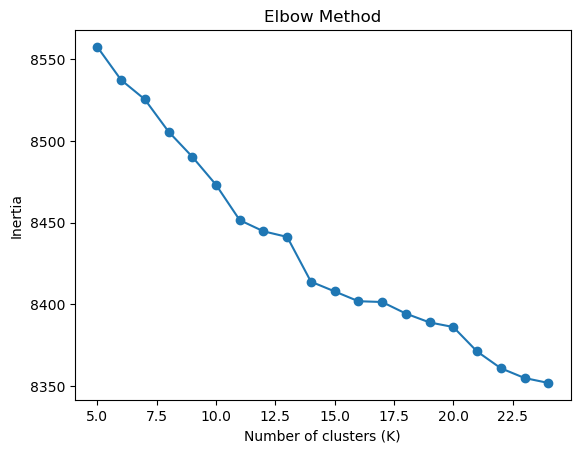

In [30]:
inertias = []
k_range = range(5, 25)

for k in k_range:
    km_temp = KMeans(n_clusters=k, random_state=42)
    km_temp.fit(tfid_matrix)
    inertias.append(km_temp.inertia_)

plt.plot(k_range, inertias, marker='o')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

In [41]:
km = KMeans(n_clusters=12, random_state=42)
km.fit(tfid_matrix)

df['cluster'] = km.labels_
print(df['cluster'].value_counts())

cluster
6     2033
5     1286
1      991
8      835
10     723
2      613
4      572
0      541
11     398
9      376
3      347
7       92
Name: count, dtype: int64


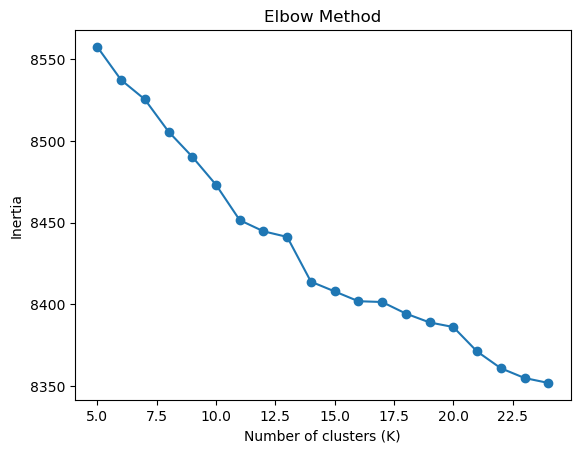

In [39]:
inertias = []
k_range = range(5, 25)

for k in k_range:
    km_temp = KMeans(n_clusters=k, random_state=42)
    km_temp.fit(tfid_matrix)
    inertias.append(km_temp.inertia_)

plt.plot(k_range, inertias, marker='o')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

In [42]:
for i in range(12):
    top_genre = df[df['cluster'] == i]['listed_in'].str.split(', ').explode().value_counts().index[0]
    size = len(df[df['cluster'] == i])
    print(f"Cluster {i}: {top_genre} ({size} titles)")

Cluster 0: Thrillers (541 titles)
Cluster 1: Action & Adventure (991 titles)
Cluster 2: Children & Family Movies (613 titles)
Cluster 3: Docuseries (347 titles)
Cluster 4: Kids' TV (572 titles)
Cluster 5: International TV Shows (1286 titles)
Cluster 6: Comedies (2033 titles)
Cluster 7: Cult Movies (92 titles)
Cluster 8: Dramas (835 titles)
Cluster 9: Music & Musicals (376 titles)
Cluster 10: Documentaries (723 titles)
Cluster 11: Stand-Up Comedy (398 titles)


In [43]:
df['cluster'] = df['cluster'].replace(11, 6)

In [47]:
def find_similar(title, df):
    cluster = df[df['title'] == title]['cluster'].values[0]
    return df[(df['cluster'] == cluster) & (df['title'] != title)]['title'].head(5).tolist()

In [45]:
find_similar("Jaws", df)

['Resurrection: Ertugrul',
 'Dark Skies',
 'The Stronghold',
 'Birth of the Dragon',
 'Safe House']

In [51]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

pca_coords = pca.fit_transform(tfid_matrix)

<Axes: >

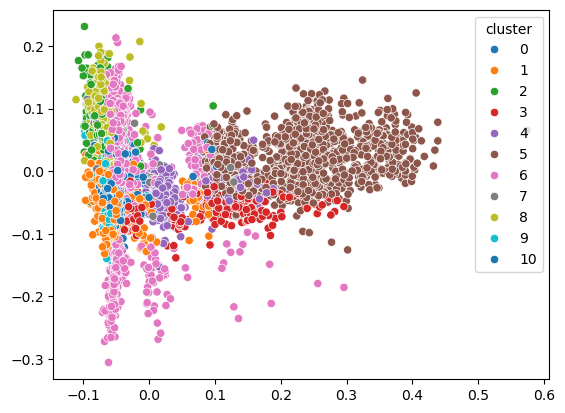

In [53]:
sns.scatterplot(x=pca_coords[:, 0], y=pca_coords[:, 1], hue=df['cluster'], palette='tab10')

In [57]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, init='random')

tsne_coords = tsne.fit_transform(tfid_matrix)

<Axes: >

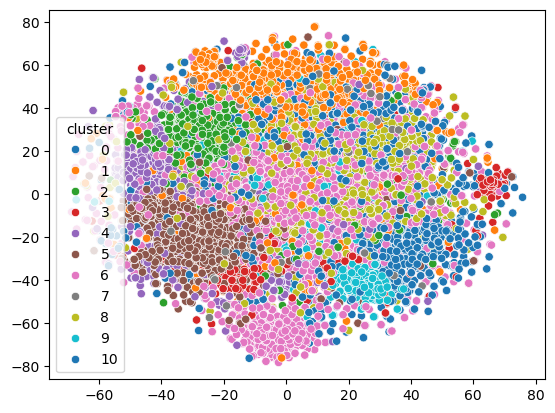

In [58]:
sns.scatterplot(x=tsne_coords[:, 0], y=tsne_coords[:, 1], hue=df['cluster'], palette='tab10')

In [59]:
from sklearn.metrics import silhouette_score

silhouette_score(tfid_matrix, df['cluster'])

0.008430511871145728

In [60]:
from sklearn.metrics.pairwise import cosine_similarity

In [68]:
similar = cosine_similarity(tfid_matrix)

In [75]:
def find_similar(title, n):
    index = df[df['title'] == title].index[0]
    sorted_indices = np.argsort(similar[index])[::-1]
    top_n = sorted_indices[1:n+1]
    return df['title'].iloc[top_n].values.tolist()

In [76]:
find_similar("Jaws", 5)

['Jaws: The Revenge', 'Jaws 2', 'Jaws 3', 'In The Deep', 'Maya Memsaab']